# Model & metric walkthrough

An interview-facing walkthrough of the **current** explicit physical model: a no-action forecast,
one EV's week, the smart-charging action model, and a small check on why Monte Carlo percentiles are
never summed. Every number here is `evidence_kind="illustrative"` or `"illustrative_synthetic"`
(see `docs/MODEL_CONTRACT.md`); nothing is observed history, a settlement, a tariff or Axle cash.

> **Import note.** Every `axle_studio.model.*` import this notebook needs lives in the single
> cell directly below (the model modules follow the layout of decision 0004 item 15: `settings`,
> `assumptions`, `sampling`, `physics`, `action`, `forecast`, `summaries`, `individual`).

**Sections**

1. Setup and illustrative labelling
2. A no-action forecast: plug-in timing, SoC and per-cohort spread across the week
3. One EV's week
4. Adding the action: smart charging, early departures and cost
5. Why we never sum percentiles (a world-first check)
6. Limitations

In [1]:
# --- MODEL IMPORTS (one cell) -----------------------------------------------
# Everything the notebook imports from axle_studio lives in this one cell, so a module rename is
# a one-cell change; no other cell imports from axle_studio directly.
from datetime import date, timedelta

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

from axle_studio.model import assumptions
from axle_studio.model.clock import utc_half_hour_boundaries
from axle_studio.model.forecast import EVIDENCE_KINDS, POLICY_IDS, run_forecast, simulate_forecast
from axle_studio.model.physics import simulate_unit_intervals
from axle_studio.ui.style import PATH_STYLES, apply_notebook_style

# "notebook_connected" embeds only the figure data and loads plotly.js from a CDN, which keeps the
# committed notebook small. GitHub does not run that script, so every chart is paired with a plain
# text table (decision 0004 item 29).
pio.renderers.default = "notebook_connected"
pd.set_option("display.width", 120)

## 1. Setup and illustrative labelling

Every input below comes from `model/assumptions.py`, the one place the model states a value
(decision 0004 item 21), and each record is labelled `source`, `illustrative` or `synthetic`;
none is observed telemetry or market data. The six source cohorts set the population; the
mileage, trip-behaviour and weather records add day-to-day randomness on top of each cohort's
fixed traits. `docs/MODEL_CONTRACT.md` and decision 0004 define these labels; this section just
reads them and shows the population and labels they describe.

In [2]:
fixture = assumptions.cohort_fixture()
# The run inputs the app uses, at their defaults (warm-up days first in the weather array).
inputs = assumptions.forecast_inputs(
    None,
    warmup_days=assumptions.SIMULATION["warmup_days"].value,
    study_days=assumptions.SIMULATION["study_days"].value,
)
mileage_cv_by_cohort = inputs["daily_miles_cv_by_cohort"]
personal_mileage_cv_by_cohort = inputs["personal_mileage_cv_by_cohort"]
trip_behaviour = inputs["trip_behaviour"]

# How many records each part of the model reads, by evidence class.
assumption_labels = (
    assumptions.assumption_rows()
    .groupby(["section", "evidence"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
assumption_labels

evidence,section,illustrative,source,synthetic
0,action,4,0,0
1,availability,3,0,0
2,carbon,4,0,0
3,cnz_context,0,4,0
4,cohort_shares,6,0,0
5,cohorts,8,34,0
6,connection_clocks,16,0,0
7,connection_windows,4,0,0
8,home_charging,4,0,0
9,mileage_cv,12,0,0


In [3]:
cohort_table = pd.DataFrame(
    [
        {
            "cohort_id": cohort.cohort_id,
            "source_name": cohort.source_name,
            "share_%": round(100 * cohort.population_share_fraction, 1),
            "battery_kWh": cohort.battery_capacity_kwh,
            "daily_miles_mean": cohort.daily_miles_mean,
            "plug_probability": cohort.plug_probability,
            "arrival": f"{cohort.arrival_local_hour:02d}:00",
            "departure": f"{cohort.departure_local_hour:02d}:00",
        }
        for cohort in fixture.cohorts
    ]
)
cohort_table

,cohort_id,source_name,share_%,battery_kWh,daily_miles_mean,plug_probability,arrival,departure
0,average_uk,Average (UK),40.0,60.0,25.849315,1.0,18:00,07:00
1,intelligent_octopus,Intelligent Octopus average,30.0,72.5,77.000000,1.0,18:00,07:00
2,infrequent_charging,Infrequent charging,10.0,60.0,25.849315,0.2,18:00,07:00
3,infrequent_driving,Infrequent driving,10.0,60.0,15.616438,1.0,18:00,07:00
4,scheduled_charging,Scheduled charging,9.0,60.0,25.849315,1.0,22:00,09:00
5,always_plugged_in,Always plugged-in,1.0,60.0,25.849315,1.0,15:00,14:00


## 2. A no-action forecast: plug-in timing, SoC and per-cohort spread across the week

`simulate_forecast(..., model="no_action")` samples one persistent 200-EV population (seed 42) and simulates
20 independent **evaluation worlds** — 20 alternative simulated weeks for the same population, not
20 different fleets. The charts below show the **spread across those simulated weeks** (decision
0004 item 26), never a spread across EVs; a single EV's own week comes in section 3. There is no
wholesale action yet, so the aggregator duplicates `path_id` into identical `normal`/`selected`
rows; every chart here uses `normal` only.

In [4]:
base_temperature_c_by_day = inputs["base_temperature_c_by_day"]
weather_sd_c = inputs["weather_sd_c"]

# Reused for the action run in section 4 too, so both forecasts describe the same 200-EV,
# seed-42 population and the same 20 simulated weeks (the paired normal/selected comparison in
# section 4 relies on both paths sharing one population and one set of evaluation worlds).
# Everything else is the app's default: a settled start (80 % opening SoC, decision 0004
# item 36) after a seven-day warm-up (item 52, editable 3-14 days) and one 7 kW home
# charging power (item 34).
settings = assumptions.run_settings(
    {"vehicle_count": 200, "evaluation_world_count": 20, "seed": 42}, date(2026, 1, 12)
)

no_action = simulate_forecast(
    settings,
    fixture,
    daily_miles_cv_by_cohort=mileage_cv_by_cohort,
    personal_mileage_cv_by_cohort=personal_mileage_cv_by_cohort,
    trip_behaviour=trip_behaviour,
    base_temperature_c_by_day=base_temperature_c_by_day,
    weather_sd_c=weather_sd_c,
    public_charge_assumptions=inputs["public_charge_assumptions"],
    model="no_action",
)
pd.DataFrame(
    [
        {
            "policy_id": POLICY_IDS["no_action"],
            "evidence_kind": EVIDENCE_KINDS["no_action"],
            "vehicle_count": settings.vehicle_count,
            "evaluation_world_count": settings.evaluation_world_count,
            "study_days": settings.study_days,
        }
    ]
)

,policy_id,evidence_kind,vehicle_count,evaluation_world_count,study_days
0,explicit_no_action_v1,illustrative,200,20,7


Charts below share one small helper: a P10-P50-P90 band per path, coloured through the shared
`PATH_STYLES` used by the dashboard (decision 0004 item 29), with the median (P50) as the named
centre line and a ~30%-opacity band (decision 0004 item 27), styled with `apply_notebook_style` --
the app's own tokens on a light, GitHub-readable background (chart audit B8). Each chart's x-axis
is London local time; UTC stays available in the median line's hover text, and every chart is
paired with a small text table since GitHub does not run the embedded Plotly script. Every
half-hourly point is plotted -- decision 0004 item 33 states notebook file size and runtime are
not acceptance gates, so nothing here is downsampled (chart audit B9); the paired table underneath
still summarises to one row per day.

In [5]:
def _hex_to_rgba(hex_color: str, alpha: float) -> str:
    """Convert a `#RRGGBB` colour to `rgba(...)` at the given opacity."""
    red, green, blue = (int(hex_color[index : index + 2], 16) for index in (1, 3, 5))
    return f"rgba({red},{green},{blue},{alpha})"


def _band_traces(rows: pd.DataFrame, *, metric: str, path_id: str, name: str) -> list[go.Scatter]:
    """P10-P90 fill plus a named P50 line for one path and one metric, at full resolution."""
    style = PATH_STYLES[path_id]
    local_start = rows["interval_start_utc"].dt.tz_convert("Europe/London")
    utc_text = rows["interval_start_utc"].dt.strftime("%Y-%m-%d %H:%M")
    lower = go.Scatter(
        x=local_start,
        y=rows[f"{metric}_p10"].round(3),
        mode="lines",
        line={"width": 0},
        showlegend=False,
        hoverinfo="skip",
    )
    upper = go.Scatter(
        x=local_start,
        y=rows[f"{metric}_p90"].round(3),
        mode="lines",
        line={"width": 0},
        fill="tonexty",
        fillcolor=_hex_to_rgba(style["color"], 0.3),
        name=f"{name} P10-P90",
        legendgroup=name,
        hoverinfo="skip",
    )
    hover = (
        f"{name}<br>%{{x|%a %H:%M}} London (%{{customdata}} UTC)<br>P50: %{{y:.3f}}<extra></extra>"
    )
    median = go.Scatter(
        x=local_start,
        y=rows[f"{metric}_p50"].round(3),
        mode="lines",
        line={"color": style["color"], "dash": style["dash"], "width": 2},
        name=f"{name} P50",
        legendgroup=name,
        customdata=utc_text,
        hovertemplate=hover,
    )
    return [lower, upper, median]


def _band_figure(
    bands: pd.DataFrame,
    *,
    metric: str,
    unit: str,
    title: str,
    paths: tuple[tuple[str, str], ...],
    height: int = 420,
) -> go.Figure:
    """Time-series P10-P50-P90 band chart, one or two paired paths (decision 0004 item 27)."""
    figure = go.Figure()
    for path_id, name in paths:
        rows = bands.loc[bands["path_id"] == path_id].sort_values("interval_start_utc")
        for trace in _band_traces(rows, metric=metric, path_id=path_id, name=name):
            figure.add_trace(trace)
    figure.update_layout(
        title=title,
        xaxis_title="London local time",
        yaxis_title=unit,
        legend_title="Path and band",
        margin={"l": 60, "r": 20, "t": 70, "b": 50},
    )
    return apply_notebook_style(figure, height=height)


def _daily_summary(bands: pd.DataFrame, metric: str, path_ids: tuple[str, ...]) -> pd.DataFrame:
    """Collapse a half-hourly band frame to one daily P10/P50/P90 row per path.

    This is the small text table decision 0004 item 29 asks for next to every chart, since GitHub
    does not run the `notebook_connected` script that renders the embedded Plotly figure.
    """
    rows = bands.loc[bands["path_id"].isin(path_ids)].copy()
    rows["local_date"] = rows["interval_start_utc"].dt.tz_convert("Europe/London").dt.date
    columns = [f"{metric}_p10", f"{metric}_p50", f"{metric}_p90"]
    summary = rows.groupby(["path_id", "local_date"], as_index=False)[columns].mean().round(3)
    return summary.sort_values(["local_date", "path_id"]).reset_index(drop=True)

### Plug-in timing across the week

`connected_share` is the fraction of the fleet with a full half-hour of home connection in that
slot, aggregated **world-first**: each world's connected count is summed before any percentile is
taken across worlds (`docs/MODEL_CONTRACT.md`, "World-first aggregation"). The band is the spread
of that fraction across the 20 simulated weeks, not across EVs within one week.

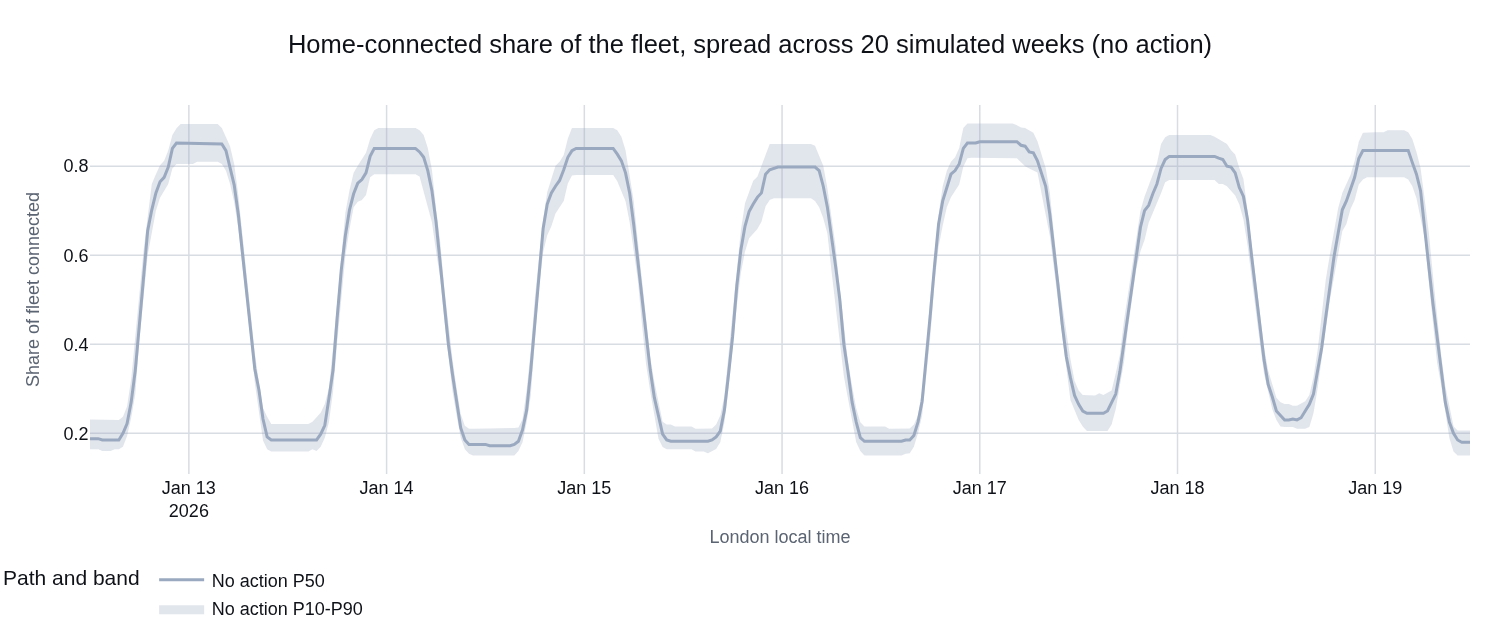

In [6]:
plugin_figure = _band_figure(
    no_action.fleet_interval_bands,
    metric="connected_share",
    unit="Share of fleet connected",
    title="Home-connected share of the fleet, spread across 20 simulated weeks (no action)",
    paths=(("normal", "No action"),),
)
plugin_figure

In [7]:
_daily_summary(no_action.fleet_interval_bands, "connected_share", ("normal",))

,path_id,local_date,connected_share_p10,connected_share_p50,connected_share_p90
0,normal,2026-01-12,0.438,0.473,0.518
1,normal,2026-01-13,0.491,0.529,0.569
2,normal,2026-01-14,0.474,0.519,0.559
3,normal,2026-01-15,0.466,0.511,0.552
4,normal,2026-01-16,0.466,0.516,0.553
5,normal,2026-01-17,0.568,0.610,0.651
6,normal,2026-01-18,0.553,0.596,0.637
7,normal,2026-01-19,0.526,0.574,0.615


### SoC across the week

`closing_soc_percent` is total battery stock divided by total physical capacity at the end of each
half-hour — a capacity-weighted fleet SoC, not an unweighted average of per-EV SoC
(`docs/MODEL_CONTRACT.md`, "World-first aggregation"). The band again shows spread across the 20
simulated weeks.

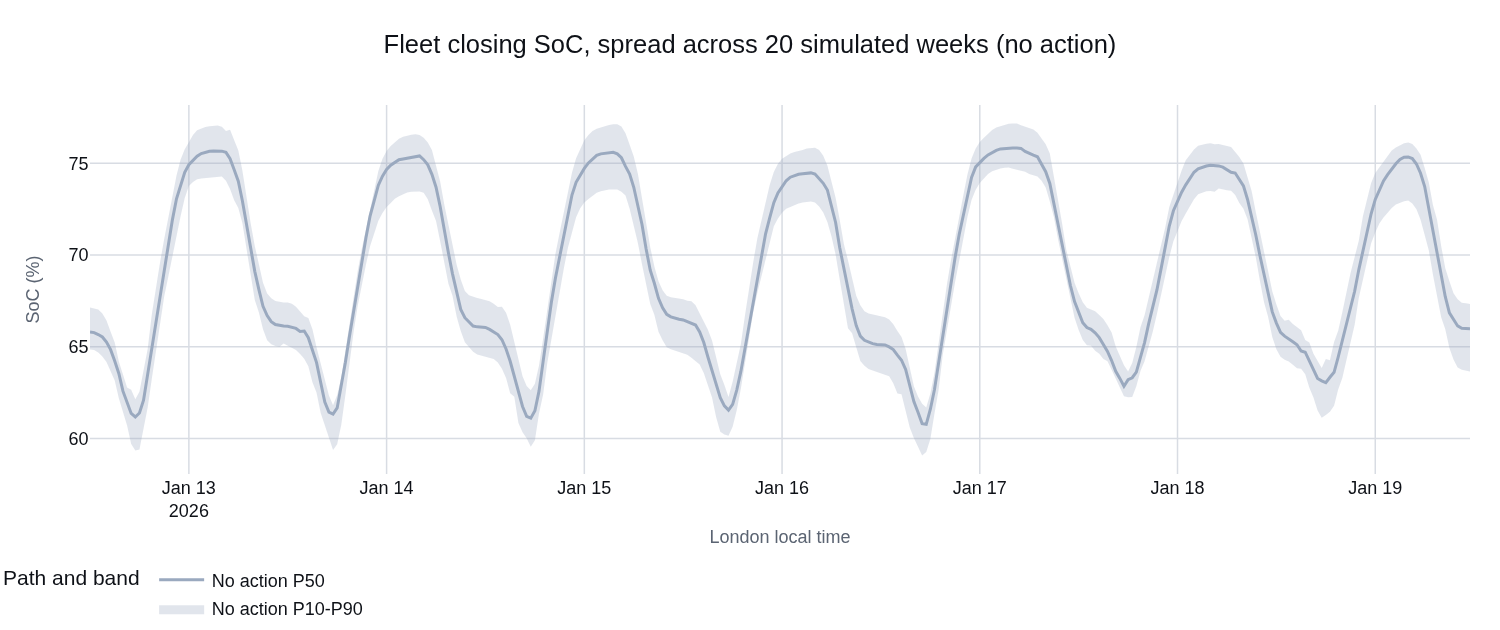

In [8]:
soc_figure = _band_figure(
    no_action.fleet_interval_bands,
    metric="closing_soc_percent",
    unit="SoC (%)",
    title="Fleet closing SoC, spread across 20 simulated weeks (no action)",
    paths=(("normal", "No action"),),
)
soc_figure

In [9]:
_daily_summary(no_action.fleet_interval_bands, "closing_soc_percent", ("normal",))

,path_id,local_date,closing_soc_percent_p10,closing_soc_percent_p50,closing_soc_percent_p90
0,normal,2026-01-12,64.670,66.138,67.417
1,normal,2026-01-13,67.832,69.273,70.393
2,normal,2026-01-14,67.417,69.102,70.512
3,normal,2026-01-15,67.480,69.130,70.551
4,normal,2026-01-16,66.911,68.497,69.785
5,normal,2026-01-17,69.065,70.051,71.293
6,normal,2026-01-18,68.032,69.483,70.734
7,normal,2026-01-19,69.298,71.527,72.754


### Per-cohort spread

The same P10-P50-P90 band, one small subplot per cohort, still spread across simulated weeks
(decision 0004 item 26 sizes each small-multiple subplot to at least 220 px; the six subplots below
are about 260 px each). `always_plugged_in` and `infrequent_charging` sit at the two extremes of
`plug_probability` from the section 1 cohort table; the rest cluster around the fleet's usual
overnight charging pattern.

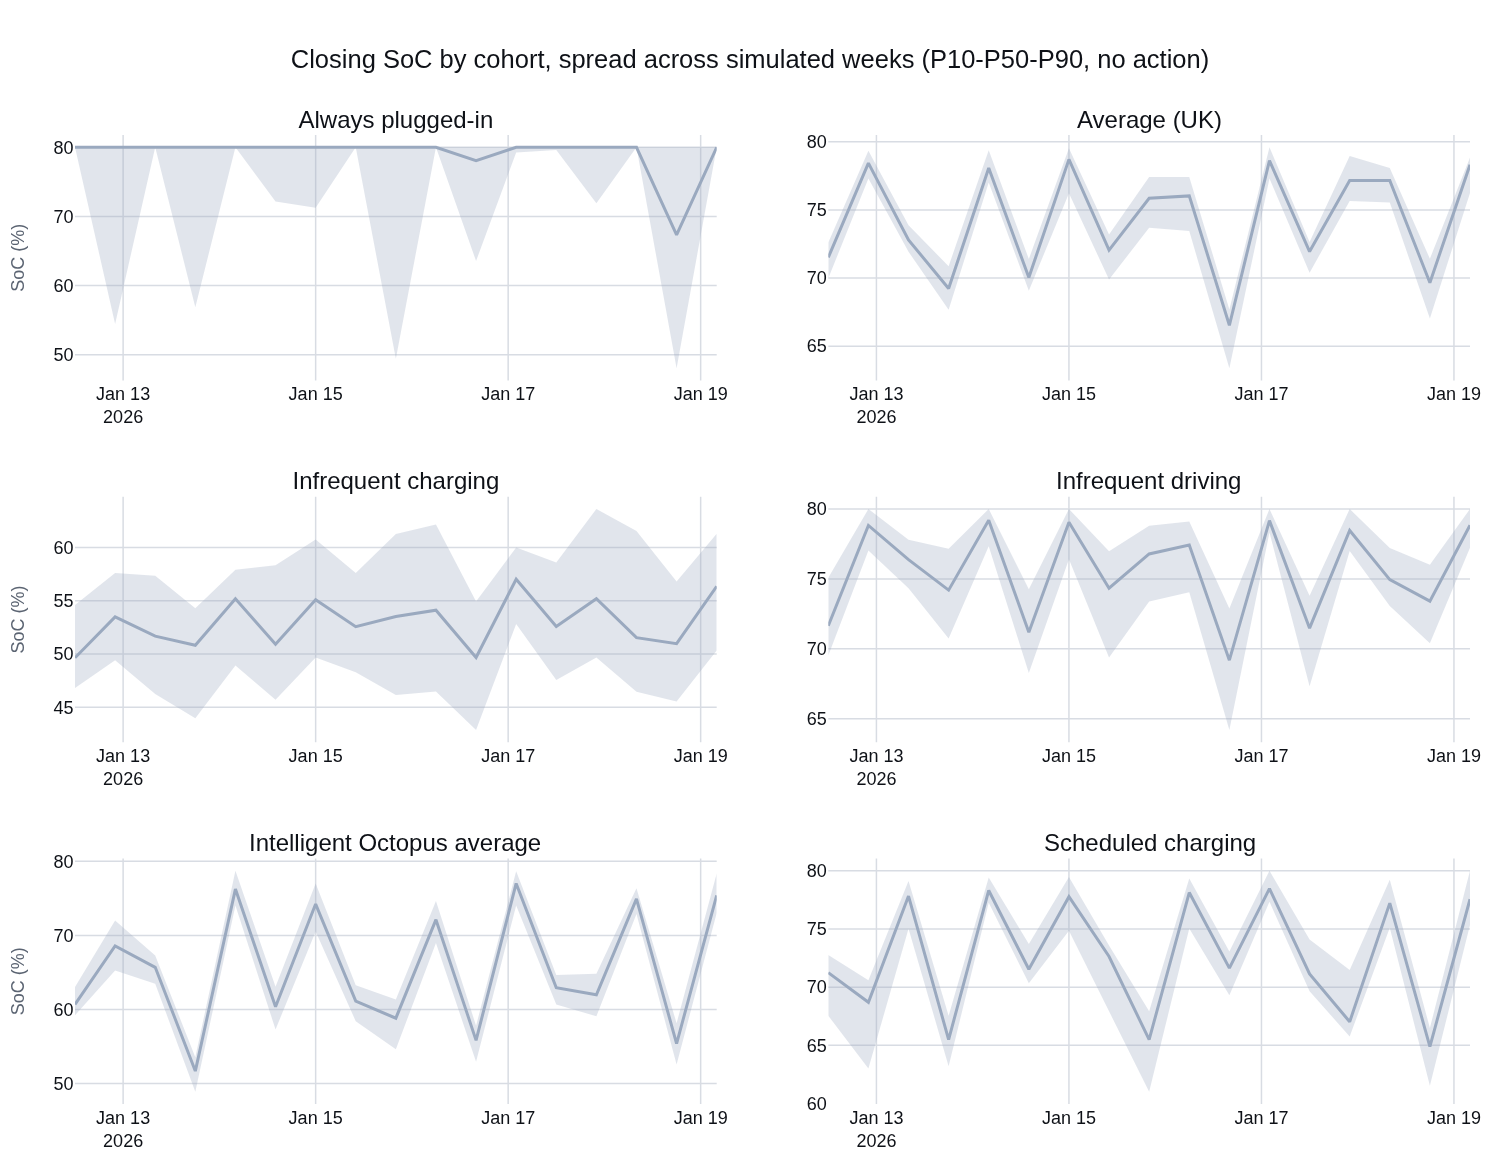

In [10]:
cohort_bands_normal = no_action.cohort_interval_distribution.query("path_id == 'normal'")
cohort_ids = sorted(cohort_bands_normal["cohort_id"].unique())
cohort_style = PATH_STYLES["normal"]
cohort_fill = _hex_to_rgba(cohort_style["color"], 0.3)
# Readable panel titles (chart audit O8): the fixture's own human-readable name per cohort_id,
# not the raw identifier used elsewhere as a dataframe key.
cohort_display_name = {cohort.cohort_id: cohort.source_name for cohort in fixture.cohorts}

cohort_figure = make_subplots(
    rows=3,
    cols=2,
    subplot_titles=[cohort_display_name[cohort_id] for cohort_id in cohort_ids],
    vertical_spacing=0.12,
    horizontal_spacing=0.08,
)
_COHORT_DOWNSAMPLE_STEP = 20  # 18 traces share this grid, so downsample harder than single charts.
for index, cohort_id in enumerate(cohort_ids):
    row, col = divmod(index, 2)
    rows = (
        cohort_bands_normal.loc[cohort_bands_normal["cohort_id"] == cohort_id]
        .sort_values("interval_start_utc")
        .iloc[::_COHORT_DOWNSAMPLE_STEP]
    )
    local_start = rows["interval_start_utc"].dt.tz_convert("Europe/London")
    cohort_figure.add_trace(
        go.Scatter(
            x=local_start,
            y=rows["closing_soc_percent_p10"].round(2),
            mode="lines",
            line={"width": 0},
            showlegend=False,
            hoverinfo="skip",
        ),
        row=row + 1,
        col=col + 1,
    )
    cohort_figure.add_trace(
        go.Scatter(
            x=local_start,
            y=rows["closing_soc_percent_p90"].round(2),
            mode="lines",
            line={"width": 0},
            fill="tonexty",
            fillcolor=cohort_fill,
            showlegend=False,
            hoverinfo="skip",
        ),
        row=row + 1,
        col=col + 1,
    )
    cohort_figure.add_trace(
        go.Scatter(
            x=local_start,
            y=rows["closing_soc_percent_p50"].round(2),
            mode="lines",
            line={"color": cohort_style["color"], "width": 2},
            showlegend=False,
        ),
        row=row + 1,
        col=col + 1,
    )
cohort_figure.update_layout(
    title="Closing SoC by cohort, spread across simulated weeks (P10-P50-P90, no action)",
    margin={"l": 50, "r": 20, "t": 90, "b": 40},
)
cohort_figure.update_yaxes(title_text="SoC (%)", col=1)
apply_notebook_style(cohort_figure, height=780)

In [11]:
cohort_pivot = (
    cohort_bands_normal.assign(
        local_date=lambda frame: frame["interval_start_utc"].dt.tz_convert("Europe/London").dt.date
    )
    .groupby(["local_date", "cohort_id"])["closing_soc_percent_p50"]
    .mean()
    .unstack("cohort_id")
    .round(1)
)
cohort_pivot

cohort_id,always_plugged_in,average_uk,infrequent_charging,infrequent_driving,intelligent_octopus,scheduled_charging
local_date,,,,,,
2026-01-12,78.2,72.5,50.3,74.2,60.0,68.9
2026-01-13,80.0,74.2,52.1,76.4,65.6,73.0
2026-01-14,80.0,74.0,53.0,75.8,65.2,73.0
2026-01-15,80.0,74.2,53.1,75.7,65.2,73.4
2026-01-16,78.5,73.6,52.9,74.5,64.5,73.0
2026-01-17,79.0,75.1,54.0,75.6,67.1,72.7
2026-01-18,77.9,74.6,52.8,75.0,66.0,72.2
2026-01-19,80.0,75.4,55.6,76.9,68.8,75.8


## 3. One EV's week

The fleet-level bands above hide any single vehicle's story. This section replays one `average_uk`
EV directly: `simulate_unit_intervals` runs the same physical kernel as the fleet aggregator but
keeps one world x EV slice instead of summing it away, and the raw sampled connection window shows
when that EV's home-plug session was actually accepted each day.

In [12]:
cohort_mask = (no_action.units["cohort_id"] == "average_uk").to_numpy()
unit_position = int(np.flatnonzero(cohort_mask)[0])
unit_row = no_action.units.iloc[unit_position]
unit_id = unit_row["unit_id"]
capacity_kwh = float(unit_row["physical_capacity_kwh"])
world_for_ev = 0

per_ev = simulate_unit_intervals(
    settings,
    no_action.units,
    no_action.evaluation.inputs,
    effective_efficiency_miles_per_battery_kwh=(
        no_action.evaluation.effective_efficiency_miles_per_battery_kwh
    ),
    public_top_up=no_action.public_top_up,
)
soc_percent = per_ev["closing_battery_kwh"][world_for_ev, :, unit_position] / capacity_kwh * 100

study_boundaries = pd.DatetimeIndex(
    utc_half_hour_boundaries(
        settings.start_local_date,
        settings.warmup_days,
        settings.study_days,
    )
)
study_interval_start_utc = study_boundaries[settings.warmup_days * 48 : -1]
soc_series = pd.DataFrame(
    {"interval_start_utc": study_interval_start_utc, "soc_percent": soc_percent.round(2)}
)
soc_series["interval_start_local"] = soc_series["interval_start_utc"].dt.tz_convert("Europe/London")

connection_accepted = no_action.evaluation.inputs["connection_session_accepted"]
connection_start = no_action.evaluation.inputs["connection_start_utc"]
connection_end = no_action.evaluation.inputs["connection_end_utc"]
connection_rows = []
for day in range(settings.study_days):
    day_index = settings.warmup_days + day
    connection_rows.append(
        {
            "local_date": settings.start_local_date + timedelta(days=day),
            "accepted": bool(connection_accepted[world_for_ev, day_index, unit_position]),
            # Sampled instants are naive datetime64 values in UTC.
            "plug_in_from_utc": pd.Timestamp(
                connection_start[world_for_ev, day_index, unit_position], tz="UTC"
            ),
            "plug_in_until_utc": pd.Timestamp(
                connection_end[world_for_ev, day_index, unit_position], tz="UTC"
            ),
        }
    )
connection_table = pd.DataFrame(connection_rows)
print(f"Replaying {unit_id} ({unit_row['cohort_id']}), evaluation world {world_for_ev}")
connection_table

Replaying ev-002 (average_uk), evaluation world 0


,local_date,accepted,plug_in_from_utc,plug_in_until_utc
0,2026-01-12,True,2026-01-12 18:00:00+00:00,2026-01-13 06:30:00+00:00
1,2026-01-13,True,2026-01-13 16:30:00+00:00,2026-01-14 07:30:00+00:00
2,2026-01-14,True,2026-01-14 19:00:00+00:00,2026-01-15 08:00:00+00:00
3,2026-01-15,True,2026-01-15 18:30:00+00:00,2026-01-16 06:30:00+00:00
4,2026-01-16,False,NaT,NaT
5,2026-01-17,True,2026-01-17 17:00:00+00:00,2026-01-18 12:30:00+00:00
6,2026-01-18,True,2026-01-18 15:00:00+00:00,2026-01-19 08:00:00+00:00


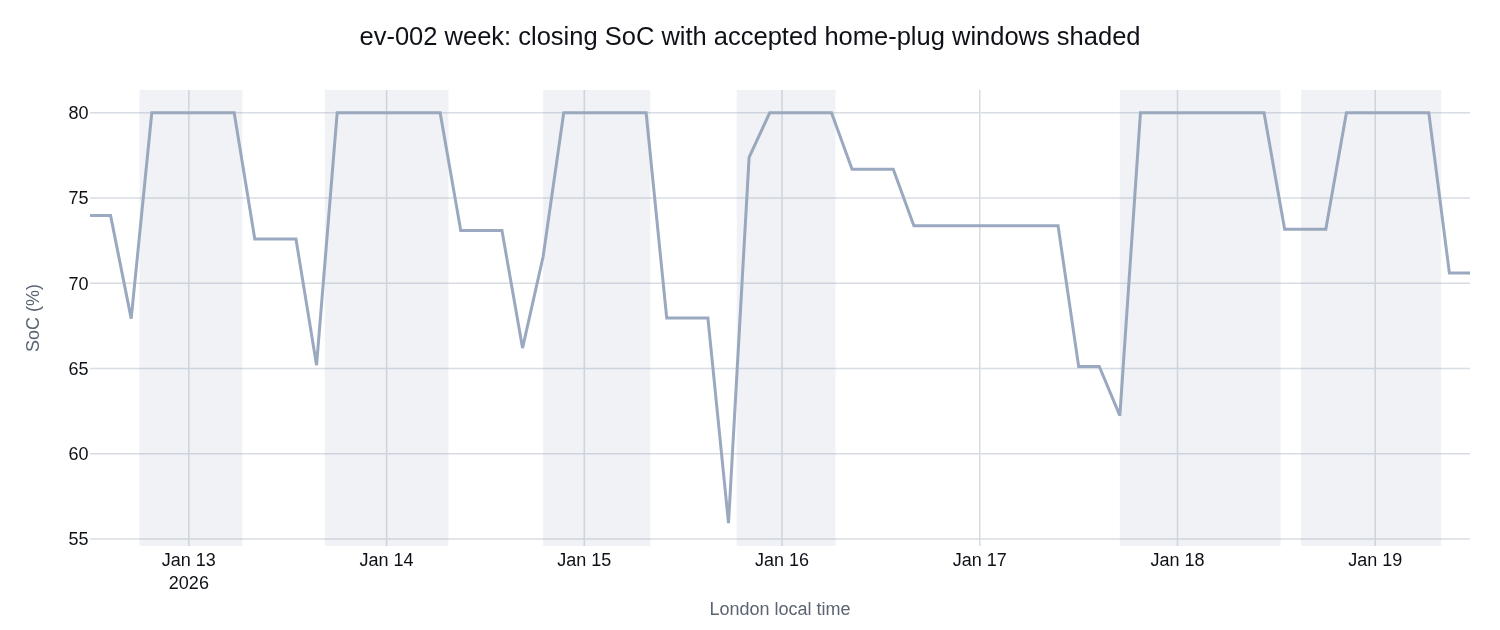

In [13]:
soc_series_plotted = soc_series.iloc[::5]  # ~2.5-hourly points; keeps chart JSON small.
soc_figure = go.Figure(
    go.Scatter(
        x=soc_series_plotted["interval_start_local"],
        y=soc_series_plotted["soc_percent"],
        mode="lines",
        line={"color": PATH_STYLES["normal"]["color"], "width": 2},
        name="Closing SoC",
    )
)
for row in connection_table.itertuples():
    if row.accepted:
        soc_figure.add_vrect(
            x0=pd.Timestamp(row.plug_in_from_utc).tz_convert("Europe/London"),
            x1=pd.Timestamp(row.plug_in_until_utc).tz_convert("Europe/London"),
            fillcolor=_hex_to_rgba(PATH_STYLES["normal"]["color"], 0.15),
            line_width=0,
        )
soc_figure.update_layout(
    title=f"{unit_id} week: closing SoC with accepted home-plug windows shaded",
    xaxis_title="London local time",
    yaxis_title="SoC (%)",
    margin={"l": 60, "r": 20, "t": 60, "b": 50},
)
apply_notebook_style(soc_figure, height=420)

## 4. Adding the action: smart charging, early departures and cost

The action model reuses the same `settings` (200 EVs, seed 42, 20 simulated weeks) and the same
random worlds as the no-action run: both models draw the population and the worlds first, and the
action model draws its price noise last. The **normal** path charges as soon as an EV is plugged in.
The **selected** path is smart home charging (decision 0004 item 38): when an EV plugs in, the
charger knows only its battery level, the plug-in half-hour, its expected departure (the cohort's
usual home departure time minus a safety margin, an editable illustrative assumption printed live
below) and its own simulated week's day-ahead prices. Each week has its own day-ahead path: that
world's own net demand (a demand shape, heating, wind, solar and any shock) runs through an
illustrative merit-order supply curve, plus a persistent daily level and half-hour AR(1) noise
(decision 0004 item 48), so the cheapest half-hour moves from night to night and week to week;
the realised price adds a separate forecast error the charger never sees. It puts just enough
energy to reach the preferred target into the cheapest
forecast half-hours before that departure, cheapest first. If the window is too short it charges at
full power throughout. The plan then meets the simulated week's *actual* departure: if the driver
leaves earlier, the rest of the plan is missed, and the shortfall shows up later as a public top-up
or as energy not recovered by the end of the week, both priced below. A session whose next departure
falls after the study week cannot see a full plan window, so it charges as soon as it is plugged in,
like the normal path (decision 0004 item 49).

That plug-in plan is not the end of the story below `simulate_forecast`'s default settings: with
`trading.intraday_dispatch` on (the default, decision 0004 item 62(b);
`docs/contracts/intraday-dispatch-v1.md`), a committed share of EVs
(`trading.day_ahead_commitment_share`, 0.8 by default) stays locked to the day-ahead plan just
described, and the other, free share re-plans every hour against the latest known price -- the
day-ahead forecast until it is published, then the latest intraday update -- moving charging out
of a slot that has turned dear and into one that has turned cheap, as far as the session can still
reach its target by its expected departure. The `action` and `action_result` runs below already
have dispatch on, so the `selected` path charted from here is this dispatched fleet, not the
day-ahead plan held fixed from plug-in; notebook 04 and 06 look at the dispatcher and its trading
split directly. Every input comes from the
same `model/assumptions.py` records the app uses (via `assumptions.forecast_inputs`).


In [14]:
public_charge_assumptions = inputs["public_charge_assumptions"]
price_assumptions = inputs["price_assumptions"]
departure_margin_hours = inputs["departure_margin_hours"]
action_arguments = dict(
    daily_miles_cv_by_cohort=mileage_cv_by_cohort,
    personal_mileage_cv_by_cohort=personal_mileage_cv_by_cohort,
    trip_behaviour=trip_behaviour,
    base_temperature_c_by_day=base_temperature_c_by_day,
    weather_sd_c=weather_sd_c,
    public_charge_assumptions=public_charge_assumptions,
    price_assumptions=price_assumptions,
    departure_margin_hours=departure_margin_hours,
    model="action",
)
# The raw simulation (kernel column names) feeds the charts below; run_forecast packages the
# same seed into the dashboard's result, which carries the smart-charging summaries.
action = simulate_forecast(settings, fixture, **action_arguments)
action_result = run_forecast(settings, fixture, **action_arguments)
print(f"policy_id={POLICY_IDS['action']!r} evidence_kind={EVIDENCE_KINDS['action']!r}")
print(f"departure margin: {departure_margin_hours:g} h")

policy_id='explicit_synthetic_wholesale_v1' evidence_kind='illustrative_synthetic'
departure margin: 2 h


### What smart charging did, week by week

`smart_charging_world` has one row per simulated week: the average price the fleet actually paid
for home charging on each path (weighted by the week's realised prices: the day-ahead prices it
planned on plus a forecast error it never saw), how much home charging moved to other half-hours, and the *early departures*: sessions whose
EV left before its plan finished, with the battery energy the plan still owed. `smart_charging_summary`
then takes P10/P50/P90 of each across weeks; the price change is taken inside each week first.


In [15]:
action_result.smart_charging_world.round(2)

,world_id,normal_average_price_gbp_per_mwh,selected_average_price_gbp_per_mwh,moved_home_import_kwh,moved_home_import_share,early_departure_count,early_departure_shortfall_kwh,evidence_kind
0,0,99.66,65.05,10480.85,0.61,7,25.81,illustrative_synthetic
1,1,80.27,47.39,10917.62,0.64,8,32.99,illustrative_synthetic
2,2,92.08,59.73,12361.34,0.70,8,24.96,illustrative_synthetic
3,3,97.98,65.51,11438.69,0.69,18,56.71,illustrative_synthetic
4,4,112.48,84.03,11347.59,0.67,6,31.71,illustrative_synthetic
5,5,95.40,55.86,12408.87,0.72,10,35.78,illustrative_synthetic
6,6,69.55,35.03,12324.65,0.74,6,21.22,illustrative_synthetic
7,7,92.45,68.64,10450.00,0.60,3,15.32,illustrative_synthetic
8,8,118.03,66.12,12806.87,0.78,15,54.00,illustrative_synthetic
9,9,84.63,38.81,12846.13,0.75,13,42.64,illustrative_synthetic


In [16]:
action_result.smart_charging_summary.round(3)

,metric,unit,world_count,mean,p10,p50,p90
0,normal_average_price_gbp_per_mwh,GBP/MWh,20,89.624,66.146,92.264,113.037
1,selected_average_price_gbp_per_mwh,GBP/MWh,20,56.496,34.062,57.793,80.346
2,average_price_change_gbp_per_mwh,GBP/MWh,20,-33.128,-41.772,-32.408,-23.957
3,moved_home_import_share,fraction,20,0.679,0.605,0.680,0.747
4,early_departure_count,sessions per week,20,11.150,5.700,11.500,17.100
5,early_departure_shortfall_kwh,kWh per week,20,39.827,20.628,38.013,60.429


### Where the energy moved: forecast-price thirds

`price_band_shift` splits each simulated week's study half-hours into thirds by that week's own
day-ahead price (the prices its charger ranked, decision 0004 item 48) and, per London date,
gives normal minus selected home import in each third (positive: moved out of that third). Energy
leaves the dearest third and lands in the cheapest.
On the last day little moves: a session whose next departure falls after the study week charges as
normal (decision 0004 item 49).


In [17]:
action_result.price_band_shift[
    ["day_label", "price_band", "mean_slot_count", "p10", "p50", "p90"]
].round(1)

,day_label,price_band,mean_slot_count,p10,p50,p90
0,Mon 12,low,13.2,-1981.1,-563.0,0.0
1,Mon 12,middle,14.4,-1389.9,-3.4,755.7
2,Mon 12,high,20.4,0.0,1070.6,2068.4
3,Tue 13,low,15.0,-2070.5,-1199.7,-13.4
4,Tue 13,middle,15.2,-1101.6,12.5,1160.9
5,Tue 13,high,17.8,0.0,1078.8,2047.3
6,Wed 14,low,15.8,-2045.6,-1528.8,-403.2
7,Wed 14,middle,17.8,-51.4,573.8,1262.1
8,Wed 14,high,14.4,111.8,778.6,1523.7
9,Thu 15,low,17.8,-1596.8,-725.8,-0.0


### Normal vs selected fleet import

Both paths share the same population and the same 20 simulated weeks; only the selected path
follows the smart plans. Reading the *gap* between the two P50 lines as a "saving" would be
tempting but wrong for the reason section 5 sets out: each band is already a world-first percentile
of its own path, so subtracting percentiles does not equal the percentile of the per-world
difference. `cost_effect` (next) instead differences each world's own paired
normal/selected totals *before* looking across worlds.

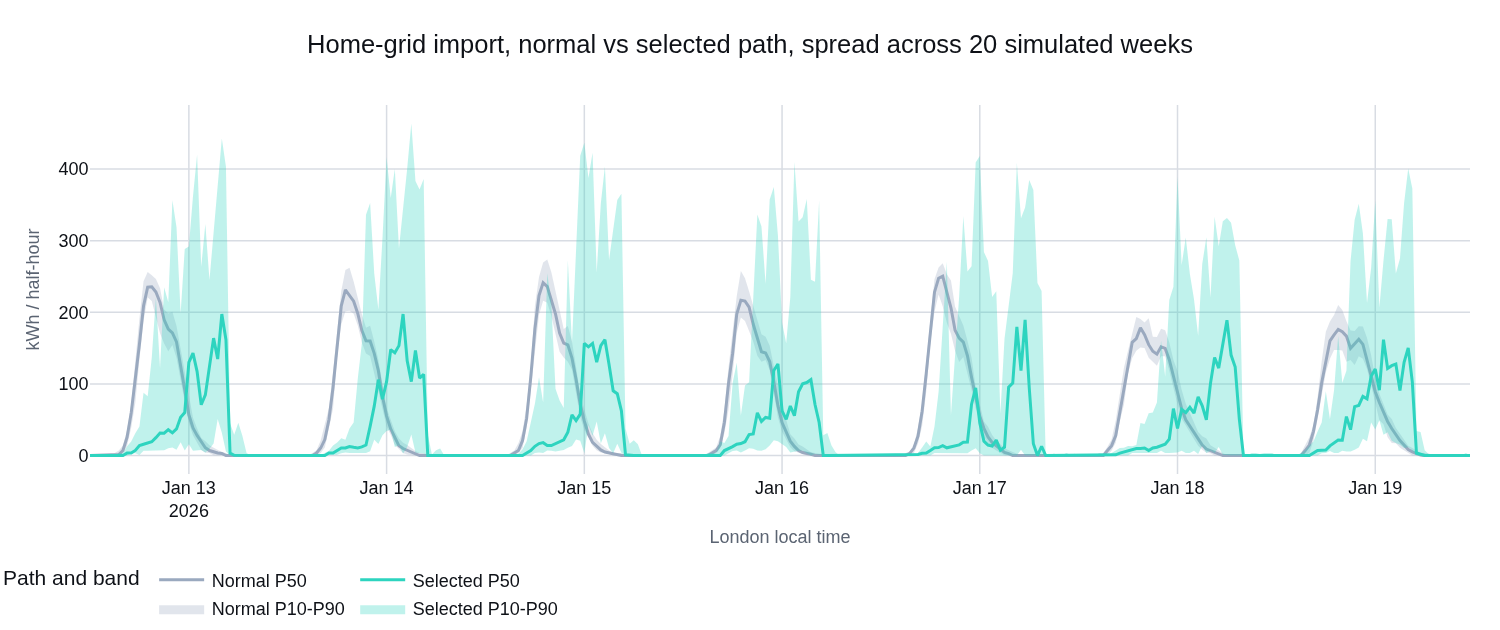

In [18]:
import_figure = _band_figure(
    action.fleet_interval_bands,
    metric="home_grid_import_kwh",
    unit="kWh / half-hour",
    title="Home-grid import, normal vs selected path, spread across 20 simulated weeks",
    paths=(("normal", "Normal"), ("selected", "Selected")),
)
import_figure

In [19]:
_daily_summary(action.fleet_interval_bands, "home_grid_import_kwh", ("normal", "selected"))

,path_id,local_date,home_grid_import_kwh_p10,home_grid_import_kwh_p50,home_grid_import_kwh_p90
0,normal,2026-01-12,84.319,99.595,114.271
1,selected,2026-01-12,4.399,16.137,98.881
2,normal,2026-01-13,42.517,50.595,59.321
3,selected,2026-01-13,5.299,35.933,114.343
4,normal,2026-01-14,42.777,50.795,60.412
5,selected,2026-01-14,5.492,35.197,125.626
6,normal,2026-01-15,38.740,46.260,55.912
7,selected,2026-01-15,6.837,39.115,132.842
8,normal,2026-01-16,43.028,52.200,61.226
9,selected,2026-01-16,2.187,22.053,108.676


### Herding: each week's own peak

Every smart EV in one simulated week ranks the same day-ahead prices, so many can pick the same
cheap half-hours. The P50 line above understates that, because the cheapest half-hour moves between
weeks and a per-slot median smooths the spikes out. So the peak is taken **inside each week first**
(its highest half-hour of fleet home import, in kW), then P10/P50/P90 across weeks (decision 0004
items 12 and 49). There is no site or network limit in the model, so nothing caps this peak.


In [20]:
# Kernel frame: per world, path and slot, fleet home import in kWh per half-hour; x2 gives kW.
weekly_peak_kw = (
    action.fleet_world_intervals.groupby(["path_id", "world_id"])["home_grid_import_kwh"].max() * 2
).unstack("path_id")
peak_table = weekly_peak_kw.quantile([0.1, 0.5, 0.9]).round(0)
peak_table.index = ["P10", "P50", "P90"]
peak_table["selected / normal"] = (
    (weekly_peak_kw["selected"] / weekly_peak_kw["normal"])
    .quantile([0.1, 0.5, 0.9])
    .round(2)
    .to_numpy()
)
peak_table

path_id,normal,selected,selected / normal
P10,515.0,867.0,1.55
P50,532.0,914.0,1.71
P90,568.0,980.0,1.82


### The cost table

`cost_effect` holds one row per evaluation world. Every `illustrative_*` column
applies an editable, labelled assumption to a physical energy difference — never a settlement, a
submitted bid or Axle cash (decision 0004 item 4; `docs/MODEL_CONTRACT.md`). `energy_not_recovered`
flags a world where the selected path ends with less battery stock, more public import, or more
unserved travel than normal (in practice, after early departures), beyond a 1e-6 kWh tolerance
(decision 0004 item 5). That flag can fire on one EV missing a single half-hour, so the table also
carries the magnitude (decision 0004 item 45): `unrecovered_kwh`, its share of the week's normal
home import (`unrecovered_share`), the plug-in sessions that ended short
(`sessions_affected_count`) and `not_recovered_material`, true when that share reaches the
illustrative 1% material threshold. Unrecovered energy is valued at the same illustrative public rate, on the basis the driver would
buy it back at a public charger. The table below shows the columns this walkthrough needs; the
full `cost_table` (`action_result.cost_effect`) also carries the public-charge and
unserved-travel components that make up the illustrative total. The printed counts are
whatever these real, editable assumptions produce for this run — it can honestly be zero, since
recovery depends on the price and public-charge values in force, not on the notebook picking a
count to show.

In [21]:
cost_table = action_result.cost_effect
not_recovered = int(cost_table["energy_not_recovered"].sum())
material = int(cost_table["not_recovered_material"].sum())
print(
    f"{not_recovered} of {len(cost_table)} evaluation worlds ended with some energy not recovered "
    f"(early departures leave EVs short); {material} reached the material threshold."
)
# The full cost_table has every intermediate component; this view keeps the columns the task asks
# for readable (world, paired import, illustrative total, not-recovered flag); the rest is still in
# cost_table itself.
cost_table[
    [
        "world_id",
        "normal_home_import_kwh",
        "selected_home_import_kwh",
        "illustrative_selected_minus_normal_total_gbp",
        "energy_not_recovered",
        "unrecovered_kwh",
        "unrecovered_share",
        "sessions_affected_count",
        "not_recovered_material",
        "evidence_kind",
    ]
].round(3)

16 of 20 evaluation worlds ended with some energy not recovered (early departures leave EVs short); 0 reached the material threshold.


,world_id,normal_home_import_kwh,selected_home_import_kwh,illustrative_selected_minus_normal_total_gbp,energy_not_recovered,unrecovered_kwh,unrecovered_share,sessions_affected_count,not_recovered_material,evidence_kind
0,0,17179.873,17170.204,-588.254,True,8.895,0.001,6,False,illustrative_synthetic
1,1,16965.653,16991.043,-554.167,True,3.220,0.000,8,False,illustrative_synthetic
2,2,17535.797,17540.491,-566.768,True,0.317,0.000,8,False,illustrative_synthetic
3,3,16572.130,16552.484,-517.390,True,27.734,0.002,18,False,illustrative_synthetic
4,4,17053.566,17053.566,-485.206,False,0.000,0.000,6,False,illustrative_synthetic
5,5,17129.746,17119.880,-660.665,True,21.836,0.001,10,False,illustrative_synthetic
6,6,16763.163,16770.163,-578.326,False,0.000,0.000,6,False,illustrative_synthetic
7,7,17509.811,17504.883,-412.674,True,5.699,0.000,2,False,illustrative_synthetic
8,8,16490.464,16431.801,-812.840,True,59.609,0.004,15,False,illustrative_synthetic
9,9,17219.334,17227.254,-784.783,True,4.967,0.000,13,False,illustrative_synthetic


## 5. Why we never sum percentiles (a world-first check)

`docs/MODEL_CONTRACT.md`'s "World-first P95" oracle states the rule this notebook, and the model,
follow everywhere: sum each additive quantity **inside every world first**, then take percentiles
**across worlds**. Never take a percentile inside each group and then combine those percentiles.
The tiny example below reproduces that oracle exactly, using the same linear-interpolation
quantile method the aggregator uses (`np.quantile(..., method="linear")` in
`model/physics.py`).

In [22]:
# Two cohorts, two worlds each, deliberately paired so neither cohort peaks in the same world as
# the other (docs/MODEL_CONTRACT.md, "World-first P95" oracle).
cohort_a_worlds = np.array([0.0, 100.0])
cohort_b_worlds = np.array([100.0, 0.0])
fleet_worlds = cohort_a_worlds + cohort_b_worlds  # sum WITHIN each world first

correct_fleet_p95 = float(np.percentile(fleet_worlds, 95, method="linear"))
naive_sum_of_marginals = float(
    np.percentile(cohort_a_worlds, 95, method="linear")
    + np.percentile(cohort_b_worlds, 95, method="linear")
)

assert correct_fleet_p95 == 100.0
assert naive_sum_of_marginals == 190.0

pd.DataFrame(
    [
        {
            "quantity": "Fleet worlds (A + B, summed world-first)",
            "value": str(fleet_worlds.tolist()),
        },
        {
            "quantity": "Correct fleet P95 (percentile of the summed worlds)",
            "value": correct_fleet_p95,
        },
        {"quantity": "Invalid: P95(cohort A) + P95(cohort B)", "value": naive_sum_of_marginals},
    ]
)

,quantity,value
0,"Fleet worlds (A + B, summed world-first)","[100.0, 100.0]"
1,Correct fleet P95 (percentile of the summed wo...,100.0
2,Invalid: P95(cohort A) + P95(cohort B),190.0


Fleet P95 is 100, not the invalid marginal-percentile sum of 190: cohort A and cohort B never both
peak in the same world, so summing their separately-computed P95s invents a combined peak that no
single simulated world ever produced. This is exactly why every chart above builds a fleet or
cohort quantity by summing within each simulated week first and only then taking P10/P50/P90 across
weeks.

## 6. Limitations

- **Illustrative and synthetic only.** The cohort fixture, trip behaviour, weather and wholesale
  price paths are inventions for this interview build; the £0.79/kWh public-charge rate is a
  labelled, editable assumption, not a tariff (decision 0004 item 4). None of this is calibrated
  to, or validated against, real telemetry or market data.
- **No shared site cap in this runner.** `simulate_forecast` limits each EV, in both models,
  only by its own home charging power (decision 0004 item 34), so no shared fleet-site import
  cap is enforced.
- **One action.** Smart charging (decision 0004 item 38) is the only action evaluated. The
  six-route and daily-DFS mechanisms are removed (decision 0004 item 18) and are not reintroduced
  here.
- **A simple expected departure.** The charger expects each EV to leave at its cohort's usual
  departure time minus a fixed margin; it does not learn from a driver's history. A session whose
  next departure falls after the study week charges as normal (decision 0004 item 49), and driver
  override and battery degradation are not modelled.
- **One price signal per week, no network limit.** Every smart EV in a simulated week plans on the
  same day-ahead path, so the fleet can still bunch into that night's cheapest half-hours (the
  herding check above); prices do not respond to the fleet's own charging.
- **Small evaluation-world counts.** 20 simulated weeks give an illustrative P10-P90 band and a
  small, noisy count of materially not-recovered worlds, not a converged tail estimate.
- **Section 3 uses the accepted daily connection window, not a half-hourly plug/unplug replay.**
  The full per-half-hour physical-state trace is fleet-aggregated only in this notebook; a per-EV
  half-hourly replay is decision 0004 item 20's Individual view, not reproduced here.
- **Simple weather effect.** Efficiency derating from temperature is one linear sensitivity with
  independent daily noise; it does not model correlation across days or vehicles.